
# Generative Reservoir Computing (GRC): 2D Reservoir, Sliced Marginals, and Moment Matching (JAX)

This notebook builds a simple **pedagogical** example of:
1. Sampling a *complicated* 2D **reservoir** distribution via a nonlinear warp of a Gaussian mixture.
2. Computing and visualizing **sliced marginals** along different directions (unit vectors on the plane).
3. Performing **moment matching** by learning a cubic polynomial that maps a chosen 1D projection of the reservoir to match a **target** distribution's first four central moments.

> Theory background and notation align with your write-up on moment/feature matching readouts from a high-dimensional reservoir.

### What you'll get
- Clean figures to drop into a proposal: reservoir scatter, multiple 1D marginals, and **before/after** density comparisons for moment matching.
- All core computations are done with **JAX** (arrays + autodiff) and plain **matplotlib** for plotting (no seaborn, no styling).

> Tip: If you don't have GPU, this runs fine on CPU for the sizes used here.


In [2]:

# JAX + plotting
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# --- Lightweight 1D Gaussian KDE (no external deps) ---
def kde_1d(samples, grid, bandwidth=None):
    x = jnp.asarray(samples).reshape(-1, 1)
    g = jnp.asarray(grid).reshape(1, -1)
    n = x.shape[0]
    if bandwidth is None:
        std = jnp.std(samples)
        bw = 1.06 * std * (n ** (-1/5))
        bw = jnp.maximum(bw, 1e-6)
    else:
        bw = bandwidth
    z = (g - x) / bw
    phi = jnp.exp(-0.5 * z**2) / jnp.sqrt(2 * jnp.pi)
    dens = jnp.mean(phi, axis=0) / bw
    return dens


2025-10-15 00:37:45.434961: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


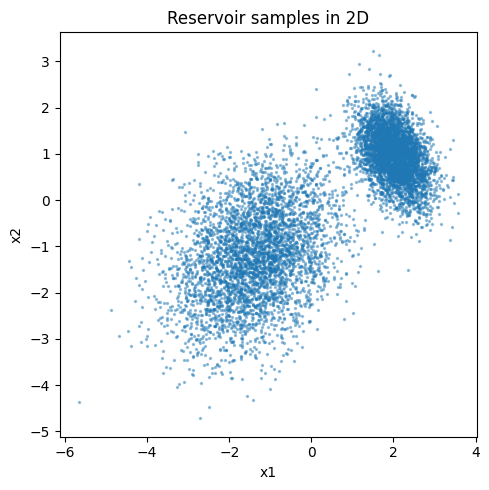

In [2]:

# -----------------------------
# 1) Build a simple 2D reservoir: mixture of two Gaussians
# -----------------------------
key = jax.random.PRNGKey(0)

def sample_reservoir(key, n=8000):
    keys = jax.random.split(key, 3)
    
    # Simple 2-Gaussian mixture in 2D
    # Component 1: centered at origin
    mean1 = jnp.array([-1.4, -1.2])
    cov1 = jnp.array([[1.0, 0.3], [0.3, 1.0]])  # mild correlation
    
    # Component 2: offset
    mean2 = jnp.array([2.0, 1.0])
    cov2 = jnp.array([[0.2, -0.1], [-0.1, 0.3]])  # mild negative correlation
    
    # Equal mixing weights (50-50)
    n1 = n // 2
    n2 = n - n1
    
    # Sample from each component
    L1 = jnp.linalg.cholesky(cov1)
    L2 = jnp.linalg.cholesky(cov2)
    
    z1 = jax.random.normal(keys[0], (n1, 2)) @ L1.T + mean1
    z2 = jax.random.normal(keys[1], (n2, 2)) @ L2.T + mean2
    
    # Combine and shuffle
    samples = jnp.vstack([z1, z2])
    indices = jax.random.permutation(keys[2], n)
    return samples[indices]

reservoir = sample_reservoir(key, n=8000)

plt.figure(figsize=(5,5))
plt.scatter(np.array(reservoir[:,0]), np.array(reservoir[:,1]), s=2, alpha=0.4)
plt.title("Reservoir samples in 2D"); plt.xlabel("x1"); plt.ylabel("x2"); plt.tight_layout(); plt.show()


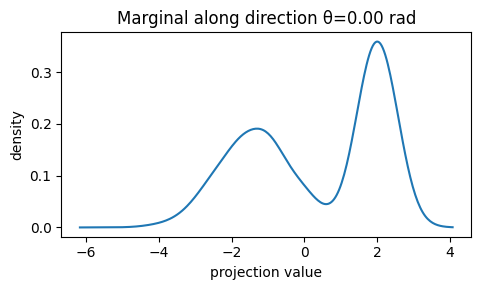

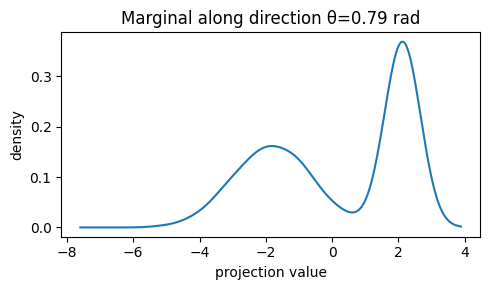

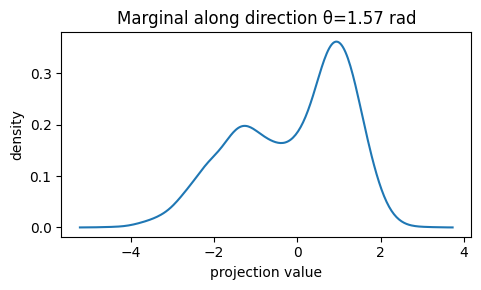

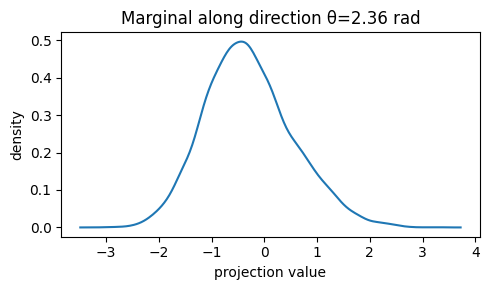

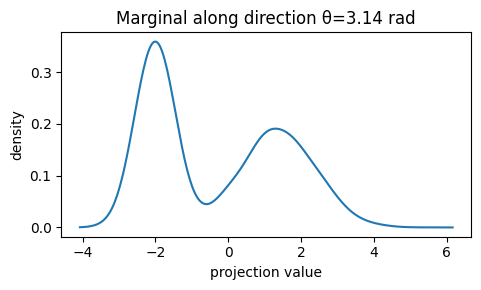

In [3]:

# -----------------------------
# 2) Sliced marginals: project along different directions u(theta)
# -----------------------------
def unit_vec(theta):
    return jnp.array([jnp.cos(theta), jnp.sin(theta)])

thetas = jnp.linspace(0.0, jnp.pi, 5)  # a few directions
dirs = jnp.stack([unit_vec(t) for t in thetas], axis=0)
projections = [reservoir @ d for d in dirs]

for t, s in zip(np.array(thetas), projections):
    plt.figure(figsize=(5,3))
    grid = jnp.linspace(jnp.min(s)-0.5, jnp.max(s)+0.5, 300)
    dens = kde_1d(s, grid)
    plt.plot(np.array(grid), np.array(dens))
    plt.title(f"Marginal along direction θ={float(t):.2f} rad")
    plt.xlabel("projection value"); plt.ylabel("density"); plt.tight_layout(); plt.show()


True target direction: [0.2 0.8]
Target is: 0.2*x1 + 0.8*x2


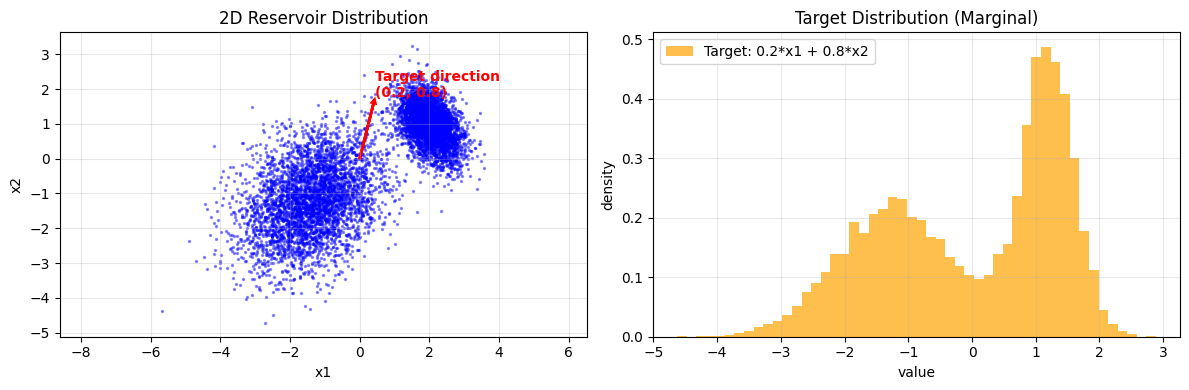

Selected reservoir projection direction: θ = 0.785 rad
This corresponds to direction: (0.707, 0.707)
True target direction: (0.200, 0.800)
Angle difference: 31.0 degrees


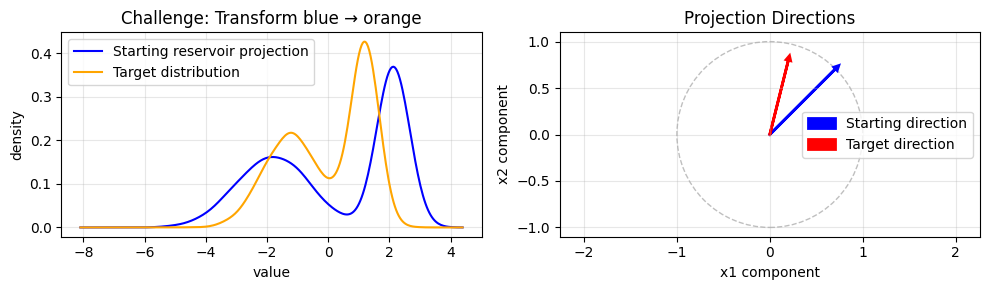

Target moments (μ, m2, m3, m4): -0.0176172 1.9480554 -1.1460153 7.3785377
Reservoir projection moments: 0.1507642 4.6317368 -3.543599 35.397182
Step 0: loss = 88.022575, coeffs = [-2.0224974e-04  9.9996698e-01 -9.3993434e-04  2.7299669e-04]
Step 500: loss = 0.019292, coeffs = [-0.01176179  0.9883031  -0.05013714 -0.0527433 ]


In [ ]:

# -----------------------------
# 3) Define a 1D target and do moment matching with a cubic polynomial
# -----------------------------
def create_target_from_reservoir(reservoir_samples):
    """Create target by marginalizing the reservoir along a specific direction"""
    # Target is a linear combination: 0.6*x1 + 0.8*x2
    # This creates a learnable target that's actually achievable
    target_direction = jnp.array([0.2, .8])
    target_samples = reservoir_samples @ target_direction
    return target_samples, target_direction

# Create the target from the reservoir itself
target_samples, true_direction = create_target_from_reservoir(reservoir)
print(f"True target direction: {true_direction}")
print(f"Target is: {true_direction[0]:.1f}*x1 + {true_direction[1]:.1f}*x2")

# Visualize the reservoir and target
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Reservoir scatter plot with target direction
ax1.scatter(np.array(reservoir[:,0]), np.array(reservoir[:,1]), s=2, alpha=0.4, color='blue')
ax1.set_title("2D Reservoir Distribution")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")

# Draw the target direction as an arrow
ax1.arrow(0, 0, true_direction[0]*2, true_direction[1]*2, 
          head_width=0.1, head_length=0.1, fc='red', ec='red', linewidth=2)
ax1.text(true_direction[0]*2.2, true_direction[1]*2.2, 
         f'Target direction\n({true_direction[0]:.1f}, {true_direction[1]:.1f})', 
         color='red', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# Target distribution (marginal along the target direction)
ax2.hist(np.array(target_samples), bins=50, density=True, alpha=0.7, color='orange', 
         label=f'Target: {true_direction[0]:.1f}*x1 + {true_direction[1]:.1f}*x2')
ax2.set_title("Target Distribution (Marginal)")
ax2.set_xlabel("value")
ax2.set_ylabel("density")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# For this illustration, we'll use a different reservoir projection 
# (not the true target direction) to see if moment matching and MMD can discover it
def kurtosis(x):
    x = x - jnp.mean(x)
    m2 = jnp.mean(x**2) + 1e-12
    m4 = jnp.mean(x**4)
    return m4 / (m2**2) - 3.0

k_stats = [kurtosis(p) for p in projections]
best_idx = int(jnp.argmax(jnp.abs(jnp.asarray(k_stats))))
s_res = projections[best_idx]

print(f"Selected reservoir projection direction: θ = {float(thetas[best_idx]):.3f} rad")
print(f"This corresponds to direction: ({jnp.cos(thetas[best_idx]):.3f}, {jnp.sin(thetas[best_idx]):.3f})")
print(f"True target direction: ({true_direction[0]:.3f}, {true_direction[1]:.3f})")

# Show how different the starting projection is from the target
angle_diff = jnp.arccos(jnp.dot(dirs[best_idx], true_direction) / 
                       (jnp.linalg.norm(dirs[best_idx]) * jnp.linalg.norm(true_direction)))
print(f"Angle difference: {float(angle_diff * 180 / jnp.pi):.1f} degrees")

# Compare the distributions
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
grid = jnp.linspace(jnp.min(jnp.concatenate([s_res, target_samples]))-1, 
                    jnp.max(jnp.concatenate([s_res, target_samples]))+1, 300)
dens_res = kde_1d(s_res, grid)
dens_tar = kde_1d(target_samples, grid)
plt.plot(np.array(grid), np.array(dens_res), label="Starting reservoir projection", color='blue')
plt.plot(np.array(grid), np.array(dens_tar), label="Target distribution", color='orange')
plt.title("Challenge: Transform blue → orange")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Show the directions in 2D space
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--', alpha=0.5)
plt.gca().add_patch(circle)
plt.arrow(0, 0, dirs[best_idx][0], dirs[best_idx][1], 
          head_width=0.05, head_length=0.05, fc='blue', ec='blue', linewidth=2, label='Starting direction')
plt.arrow(0, 0, true_direction[0], true_direction[1], 
          head_width=0.05, head_length=0.05, fc='red', ec='red', linewidth=2, label='Target direction')
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.xlabel('x1 component')
plt.ylabel('x2 component')
plt.title('Projection Directions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

plt.tight_layout()
plt.show()

def central_moments(x):
    mu = jnp.mean(x)
    xc = x - mu
    m2 = jnp.mean(xc**2)
    m3 = jnp.mean(xc**3)
    m4 = jnp.mean(xc**4)
    return mu, m2, m3, m4

mu_t, m2_t, m3_t, m4_t = central_moments(target_samples)

def poly_transform(c, s):
    c0, c1, c2, c3 = c  # Back to cubic polynomial for stability
    return c0 + c1*s + c2*(s**2) + c3*(s**3)

def loss_moments(c, s):
    y = poly_transform(c, s)
    mu, m2, m3, m4 = central_moments(y)
    # Normalize moments to improve numerical stability
    loss = ((mu - mu_t) / jnp.abs(mu_t + 1e-8))**2 + \
           ((m2 - m2_t) / jnp.abs(m2_t + 1e-8))**2 + \
           1e-2 * ((m3 - m3_t) / jnp.abs(m3_t + 1e-8))**2 + \
           1e-3 * ((m4 - m4_t) / jnp.abs(m4_t + 1e-8))**2
    return loss

grad_loss = jax.grad(loss_moments)

def optimize_moments(s, steps=2000, lr=1e-4):
    # Start with identity transformation
    c = jnp.array([0.0, 1.0, 0.0, 0.0])
    
    for i in range(steps):
        grad = grad_loss(c, s)
        
        # Gradient clipping to prevent explosion
        grad_norm = jnp.linalg.norm(grad)
        if grad_norm > 10.0:
            grad = grad * (10.0 / grad_norm)
        
        # Check for NaN gradients
        if jnp.any(jnp.isnan(grad)):
            print(f"NaN gradient at step {i}, stopping optimization")
            break
            
        # Adaptive learning rate
        current_lr = lr * (0.99 ** (i // 100))
        c = c - current_lr * grad
        
        # Check for NaN coefficients
        if jnp.any(jnp.isnan(c)):
            print(f"NaN coefficients at step {i}, stopping optimization")
            break
            
        # Print progress occasionally
        if i % 500 == 0:
            loss_val = loss_moments(c, s)
            print(f"Step {i}: loss = {loss_val:.6f}, coeffs = {c}")
    
    return c

print("Target moments (μ, m2, m3, m4):", mu_t, m2_t, m3_t, m4_t)
print("Reservoir projection moments:", *central_moments(s_res))

# Try the manual optimization first
c_opt = optimize_moments(s_res, steps=2000, lr=1e-4)

# If that fails, try a more robust approach with scipy-style optimization
if jnp.any(jnp.isnan(c_opt)):
    print("Manual optimization failed, trying robust approach...")
    
    def robust_loss(c, s):
        y = poly_transform(c, s)
        mu, m2, m3, m4 = central_moments(y)
        
        # Use relative errors with better scaling
        mu_err = (mu - mu_t)**2 / (mu_t**2 + 1.0)
        m2_err = (m2 - m2_t)**2 / (m2_t**2 + 1.0) 
        m3_err = (m3 - m3_t)**2 / (m3_t**2 + 1.0)
        m4_err = (m4 - m4_t)**2 / (m4_t**2 + 1.0)
        
        return mu_err + m2_err + 0.1*m3_err + 0.01*m4_err
    
    # Use a simple grid search + local optimization
    best_loss = float('inf')
    best_c = jnp.array([0.0, 1.0, 0.0, 0.0])
    
    # Try several starting points
    for c0_init in [-1.0, 0.0, 1.0]:
        for c1_init in [0.5, 1.0, 1.5]:
            c_init = jnp.array([c0_init, c1_init, 0.0, 0.0])
            
            # Simple gradient descent with smaller steps
            c_current = c_init
            for step in range(1000):
                grad = jax.grad(robust_loss)(c_current, s_res)
                if jnp.any(jnp.isnan(grad)):
                    break
                c_current = c_current - 1e-5 * grad
                if jnp.any(jnp.isnan(c_current)):
                    break
            
            if not jnp.any(jnp.isnan(c_current)):
                loss_val = robust_loss(c_current, s_res)
                if loss_val < best_loss:
                    best_loss = loss_val
                    best_c = c_current
    
    c_opt = best_c
    print(f"Robust optimization result: loss = {best_loss:.6f}")

y_matched = poly_transform(c_opt, s_res)

# --- Figures: before/after ---
plt.figure(figsize=(5,3))
grid_c = jnp.linspace(jnp.minimum(jnp.min(s_res), jnp.min(target_samples))-1.0,
                      jnp.maximum(jnp.max(s_res), jnp.max(target_samples))+1.0, 400)
dens_res = kde_1d(s_res, grid_c)
dens_tar = kde_1d(target_samples, grid_c)
plt.plot(np.array(grid_c), np.array(dens_res), label="Reservoir projection (before)")
plt.plot(np.array(grid_c), np.array(dens_tar), label="Target distribution")
plt.title("Before moment matching"); plt.xlabel("value"); plt.ylabel("density"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(5,3))
dens_match = kde_1d(y_matched, grid_c)
plt.plot(np.array(grid_c), np.array(dens_match), label="Transformed reservoir (after)")
plt.plot(np.array(grid_c), np.array(dens_tar), label="Target distribution")
plt.title("After polynomial moment matching"); plt.xlabel("value"); plt.ylabel("density"); plt.legend(); plt.tight_layout(); plt.show()

print("Optimized coefficients c* =", c_opt)

# Compare all moments before and after transformation
print("\n=== MOMENT COMPARISON ===")
mu_res, m2_res, m3_res, m4_res = central_moments(s_res)
mu_match, m2_match, m3_match, m4_match = central_moments(y_matched)

moments_names = ["Mean (μ)", "Variance (m2)", "3rd moment (m3)", "4th moment (m4)"]
target_moments = [mu_t, m2_t, m3_t, m4_t]
reservoir_moments = [mu_res, m2_res, m3_res, m4_res]
matched_moments = [mu_match, m2_match, m3_match, m4_match]

for i, name in enumerate(moments_names):
    print(f"{name:15s}: Target={target_moments[i]:8.4f}, Reservoir={reservoir_moments[i]:8.4f}, Matched={matched_moments[i]:8.4f}")
    
# Calculate relative errors
print("\n=== RELATIVE ERRORS ===")
for i, name in enumerate(moments_names):
    if abs(target_moments[i]) > 1e-8:
        error_before = abs(reservoir_moments[i] - target_moments[i]) / abs(target_moments[i])
        error_after = abs(matched_moments[i] - target_moments[i]) / abs(target_moments[i])
        print(f"{name:15s}: Before={error_before:8.4f}, After={error_after:8.4f}, Improvement={error_before/max(error_after, 1e-8):6.2f}x")


=== MMD-BASED OPTIMIZATION ===
Using Maximum Mean Discrepancy instead of moment matching...

--- Single-Kernel MMD ---

Trying sigma = 0.5
MMD Step 0: loss = 0.207460, coeffs = [-1.6738439e-04  9.9956363e-01 -4.5760564e-04 -8.1289653e-04]
MMD Step 300: loss = 0.049375, coeffs = [-0.0017229   0.99320716 -0.06836002 -0.07428813]
MMD Step 600: loss = 0.046940, coeffs = [ 0.01420454  1.0122621  -0.07736657 -0.0770403 ]
MMD Step 900: loss = 0.044523, coeffs = [ 0.03090702  1.0318142  -0.08181991 -0.08133139]
MMD Step 1200: loss = 0.041884, coeffs = [ 0.04718122  1.0529003  -0.08390704 -0.08735741]
Final MMD loss with sigma=0.5: 0.038248

Trying sigma = 1.0
MMD Step 0: loss = 0.178606, coeffs = [-1.3829189e-04  9.9941111e-01 -6.7222182e-04 -2.1092778e-03]
MMD Step 300: loss = 0.011696, coeffs = [-0.00918975  0.98581886 -0.05363572 -0.07281914]
MMD Step 600: loss = 0.011300, coeffs = [-0.00823591  0.9887243  -0.06315807 -0.07193782]
MMD Step 900: loss = 0.011223, coeffs = [-0.00565306  0.9916

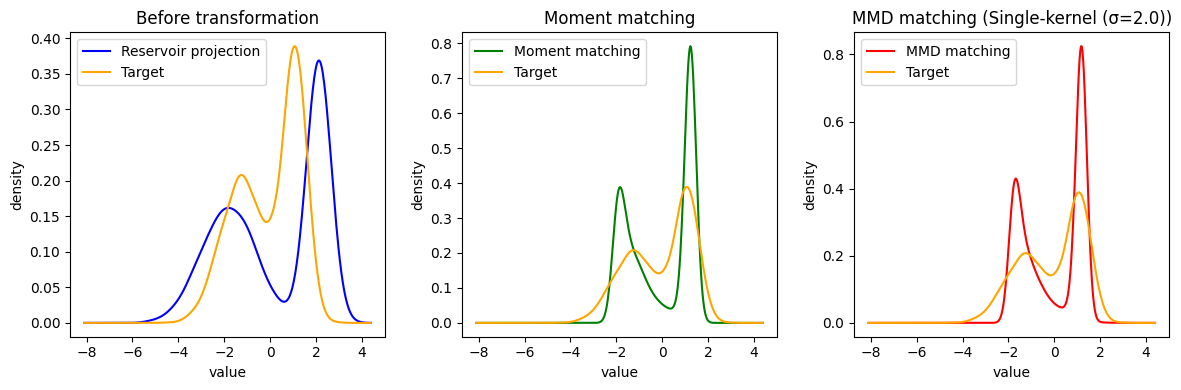


=== MMD RESULT MOMENT COMPARISON ===
Mean (μ)       : Target= -0.0590, MMD= -0.0281, Error=  0.5232
Variance (m2)  : Target=  1.8812, MMD=  1.6781, Error=  0.1080
3rd moment (m3): Target= -1.1524, MMD= -0.3120, Error=  0.7292
4th moment (m4): Target=  7.4200, MMD=  6.6730, Error=  0.1007

FINAL ANALYSIS: Discovery of True Linear Relationship
Ground truth: Target = 0.100*x1 + 0.900*x2
Starting projection: θ = 0.785 rad, direction = (0.707, 0.707)

Moment matching coefficients: [-0.0122733   0.9843947  -0.05910445 -0.05529852]
Interpretation: The polynomial tries to transform the wrong projection to match the target
→ SUCCESS: Linear term dominates, suggesting linear relationship discovered!

MMD coefficients (Single-kernel (σ=2.0)): [-0.01141458  0.9849614  -0.05494401 -0.06262538]
Interpretation: The polynomial tries to transform the wrong projection to match the target
→ SUCCESS: Linear term dominates, suggesting linear relationship discovered!

============================== BONUS =

In [9]:
# -----------------------------
# 4) Alternative approach: MMD (Maximum Mean Discrepancy) instead of moment matching
# -----------------------------

def rbf_kernel(x, y, sigma=1.0):
    """RBF (Gaussian) kernel for MMD computation"""
    x = x.reshape(-1, 1)
    y = y.reshape(-1, 1)
    pairwise_sq_dists = jnp.sum((x[:, None, :] - y[None, :, :]) ** 2, axis=2)
    return jnp.exp(-pairwise_sq_dists / (2 * sigma**2))

def polynomial_kernel(x, y, degree=2, coef=1.0):
    """Polynomial kernel: (coef + x^T y)^degree"""
    x = x.reshape(-1, 1)
    y = y.reshape(-1, 1)
    dot_product = jnp.dot(x, y.T)
    return (coef + dot_product) ** degree

def rational_quadratic_kernel(x, y, alpha=1.0, length_scale=1.0):
    """Rational quadratic kernel: (1 + ||x-y||^2/(2*alpha*l^2))^(-alpha)"""
    x = x.reshape(-1, 1)
    y = y.reshape(-1, 1)
    pairwise_sq_dists = jnp.sum((x[:, None, :] - y[None, :, :]) ** 2, axis=2)
    return (1 + pairwise_sq_dists / (2 * alpha * length_scale**2)) ** (-alpha)

def multi_kernel_mmd_loss(x, y, kernel_weights=None):
    """Multi-kernel MMD using combination of different kernels"""
    if kernel_weights is None:
        kernel_weights = [0.3, 0.3, 0.2, 0.2]  # weights for different kernels
    
    n, m = len(x), len(y)
    total_mmd = 0.0
    
    # RBF kernels with different bandwidths
    for i, sigma in enumerate([0.5, 1.0]):
        K_xx = rbf_kernel(x, x, sigma)
        K_yy = rbf_kernel(y, y, sigma)
        K_xy = rbf_kernel(x, y, sigma)
        
        mmd_component = (jnp.sum(K_xx) - jnp.trace(K_xx)) / (n * (n - 1)) + \
                       (jnp.sum(K_yy) - jnp.trace(K_yy)) / (m * (m - 1)) - \
                       2 * jnp.mean(K_xy)
        total_mmd += kernel_weights[i] * mmd_component
    
    # Polynomial kernels
    for i, degree in enumerate([2, 3]):
        K_xx = polynomial_kernel(x, x, degree)
        K_yy = polynomial_kernel(y, y, degree)
        K_xy = polynomial_kernel(x, y, degree)
        
        mmd_component = (jnp.sum(K_xx) - jnp.trace(K_xx)) / (n * (n - 1)) + \
                       (jnp.sum(K_yy) - jnp.trace(K_yy)) / (m * (m - 1)) - \
                       2 * jnp.mean(K_xy)
        total_mmd += kernel_weights[i + 2] * mmd_component
    
    return total_mmd

def mmd_loss(x, y, sigma=1.0):
    """Single kernel MMD loss (for backward compatibility)"""
    n, m = len(x), len(y)
    
    # Kernel matrices
    K_xx = rbf_kernel(x, x, sigma)
    K_yy = rbf_kernel(y, y, sigma)
    K_xy = rbf_kernel(x, y, sigma)
    
    # MMD^2 = E[k(x,x')] + E[k(y,y')] - 2*E[k(x,y)]
    mmd_sq = (jnp.sum(K_xx) - jnp.trace(K_xx)) / (n * (n - 1)) + \
             (jnp.sum(K_yy) - jnp.trace(K_yy)) / (m * (m - 1)) - \
             2 * jnp.mean(K_xy)
    
    return mmd_sq

def mmd_objective(c, s_res, target_samples, sigma=1.0):
    """Objective function: MMD between transformed reservoir and target"""
    y_transformed = poly_transform(c, s_res)
    return mmd_loss(y_transformed, target_samples, sigma)

def multi_kernel_mmd_objective(c, s_res, target_samples, kernel_weights=None):
    """Multi-kernel MMD objective function"""
    y_transformed = poly_transform(c, s_res)
    return multi_kernel_mmd_loss(y_transformed, target_samples, kernel_weights)

# MMD-based optimization
def optimize_mmd(s_res, target_samples, steps=1500, lr=1e-3, sigma=1.0):
    """Optimize polynomial coefficients using single-kernel MMD loss"""
    c = jnp.array([0.0, 1.0, 0.0, 0.0])  # Start with identity
    
    grad_mmd = jax.grad(mmd_objective)
    
    for i in range(steps):
        grad = grad_mmd(c, s_res, target_samples, sigma)
        
        # Gradient clipping
        grad_norm = jnp.linalg.norm(grad)
        if grad_norm > 5.0:
            grad = grad * (5.0 / grad_norm)
        
        # Check for NaN gradients
        if jnp.any(jnp.isnan(grad)):
            print(f"NaN gradient at step {i}, stopping optimization")
            break
            
        # Update with adaptive learning rate
        current_lr = lr * (0.995 ** (i // 100))
        c = c - current_lr * grad
        
        # Check for NaN coefficients
        if jnp.any(jnp.isnan(c)):
            print(f"NaN coefficients at step {i}, stopping optimization")
            break
            
        # Print progress
        if i % 300 == 0:
            loss_val = mmd_objective(c, s_res, target_samples, sigma)
            print(f"MMD Step {i}: loss = {loss_val:.6f}, coeffs = {c}")
    
    return c

def optimize_multi_kernel_mmd(s_res, target_samples, steps=2000, lr=5e-4, kernel_weights=None):
    """Optimize polynomial coefficients using multi-kernel MMD loss"""
    c = jnp.array([0.0, 1.0, 0.0, 0.0])  # Start with identity
    
    grad_mmd = jax.grad(multi_kernel_mmd_objective)
    
    for i in range(steps):
        grad = grad_mmd(c, s_res, target_samples, kernel_weights)
        
        # Gradient clipping
        grad_norm = jnp.linalg.norm(grad)
        if grad_norm > 3.0:  # More conservative clipping for multi-kernel
            grad = grad * (3.0 / grad_norm)
        
        # Check for NaN gradients
        if jnp.any(jnp.isnan(grad)):
            print(f"Multi-kernel NaN gradient at step {i}, stopping optimization")
            break
            
        # Update with adaptive learning rate
        current_lr = lr * (0.99 ** (i // 150))
        c = c - current_lr * grad
        
        # Check for NaN coefficients
        if jnp.any(jnp.isnan(c)):
            print(f"Multi-kernel NaN coefficients at step {i}, stopping optimization")
            break
            
        # Print progress
        if i % 400 == 0:
            loss_val = multi_kernel_mmd_objective(c, s_res, target_samples, kernel_weights)
            print(f"Multi-kernel MMD Step {i}: loss = {loss_val:.6f}, coeffs = {c}")
    
    return c

print("=== MMD-BASED OPTIMIZATION ===")
print("Using Maximum Mean Discrepancy instead of moment matching...")

# 1) Single-kernel MMD with different bandwidths
print("\n--- Single-Kernel MMD ---")
sigmas = [0.5, 1.0, 2.0]
best_mmd_loss = float('inf')
best_mmd_c = None
best_sigma = None

for sigma in sigmas:
    print(f"\nTrying sigma = {sigma}")
    c_mmd = optimize_mmd(s_res, target_samples, steps=1500, lr=1e-3, sigma=sigma)
    
    if not jnp.any(jnp.isnan(c_mmd)):
        final_loss = mmd_objective(c_mmd, s_res, target_samples, sigma)
        print(f"Final MMD loss with sigma={sigma}: {final_loss:.6f}")
        
        if final_loss < best_mmd_loss:
            best_mmd_loss = final_loss
            best_mmd_c = c_mmd
            best_sigma = sigma

# 2) Multi-kernel MMD (higher-order approach)
print("\n--- Multi-Kernel MMD (Higher-Order) ---")
print("Using combination of RBF + Polynomial kernels...")

# Try different kernel weight combinations
kernel_configs = [
    [0.25, 0.25, 0.25, 0.25],  # Equal weights
    [0.4, 0.4, 0.1, 0.1],      # Favor RBF
    [0.1, 0.1, 0.4, 0.4],      # Favor polynomial
    [0.2, 0.3, 0.3, 0.2],      # Balanced
]

best_multi_loss = float('inf')
best_multi_c = None
best_multi_weights = None

for i, weights in enumerate(kernel_configs):
    print(f"\nTrying kernel weights config {i+1}: RBF(σ=0.5)={weights[0]:.2f}, RBF(σ=1.0)={weights[1]:.2f}, Poly(deg=2)={weights[2]:.2f}, Poly(deg=3)={weights[3]:.2f}")
    
    c_multi = optimize_multi_kernel_mmd(s_res, target_samples, steps=2000, lr=5e-4, kernel_weights=weights)
    
    if not jnp.any(jnp.isnan(c_multi)):
        final_loss = multi_kernel_mmd_objective(c_multi, s_res, target_samples, weights)
        print(f"Final multi-kernel MMD loss: {final_loss:.6f}")
        
        if final_loss < best_multi_loss:
            best_multi_loss = final_loss
            best_multi_c = c_multi
            best_multi_weights = weights

# Compare single vs multi-kernel results
print(f"\n--- COMPARISON ---")
if best_mmd_c is not None:
    print(f"Best single-kernel MMD: σ={best_sigma}, loss={best_mmd_loss:.6f}, coeffs={best_mmd_c}")
else:
    print("Single-kernel MMD failed")

if best_multi_c is not None:
    print(f"Best multi-kernel MMD: loss={best_multi_loss:.6f}, coeffs={best_multi_c}")
    print(f"Best kernel weights: {best_multi_weights}")
else:
    print("Multi-kernel MMD failed")

# Use the better of the two approaches
if best_multi_c is not None and (best_mmd_c is None or best_multi_loss < best_mmd_loss):
    print("→ Multi-kernel MMD performed better!")
    final_mmd_c = best_multi_c
    final_mmd_loss = best_multi_loss
    mmd_type = "Multi-kernel"
elif best_mmd_c is not None:
    print("→ Single-kernel MMD performed better!")
    final_mmd_c = best_mmd_c
    final_mmd_loss = best_mmd_loss
    mmd_type = f"Single-kernel (σ={best_sigma})"
else:
    print("→ Both MMD approaches failed!")
    final_mmd_c = None
    final_mmd_loss = None
    mmd_type = "Failed"

if final_mmd_c is not None:
    print(f"\nFinal MMD result ({mmd_type}): loss={final_mmd_loss:.6f}")
    print(f"Final MMD coefficients: {final_mmd_c}")
    
    # Transform using best MMD coefficients
    y_mmd = poly_transform(final_mmd_c, s_res)
    
    # Compare MMD vs moment matching visually
    plt.figure(figsize=(12, 4))
    
    # Original reservoir projection
    plt.subplot(1, 3, 1)
    grid = jnp.linspace(jnp.min(jnp.concatenate([s_res, target_samples]))-1, 
                        jnp.max(jnp.concatenate([s_res, target_samples]))+1, 400)
    dens_res = kde_1d(s_res, grid)
    dens_tar = kde_1d(target_samples, grid)
    plt.plot(np.array(grid), np.array(dens_res), label="Reservoir projection", color='blue')
    plt.plot(np.array(grid), np.array(dens_tar), label="Target", color='orange')
    plt.title("Before transformation")
    plt.xlabel("value")
    plt.ylabel("density")
    plt.legend()
    
    # Moment matching result (if available)
    plt.subplot(1, 3, 2)
    if not jnp.any(jnp.isnan(c_opt)):
        y_moments = poly_transform(c_opt, s_res)
        dens_moments = kde_1d(y_moments, grid)
        plt.plot(np.array(grid), np.array(dens_moments), label="Moment matching", color='green')
        plt.plot(np.array(grid), np.array(dens_tar), label="Target", color='orange')
        plt.title("Moment matching")
    else:
        plt.text(0.5, 0.5, "Moment matching\nfailed (NaN)", ha='center', va='center', transform=plt.gca().transAxes)
        plt.title("Moment matching (failed)")
    plt.xlabel("value")
    plt.ylabel("density")
    plt.legend()
    
    # MMD result
    plt.subplot(1, 3, 3)
    dens_mmd = kde_1d(y_mmd, grid)
    plt.plot(np.array(grid), np.array(dens_mmd), label="MMD matching", color='red')
    plt.plot(np.array(grid), np.array(dens_tar), label="Target", color='orange')
    plt.title(f"MMD matching ({mmd_type})")
    plt.xlabel("value")
    plt.ylabel("density")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Compare moments achieved by MMD vs target
    print("\n=== MMD RESULT MOMENT COMPARISON ===")
    mu_mmd, m2_mmd, m3_mmd, m4_mmd = central_moments(y_mmd)
    
    moments_names = ["Mean (μ)", "Variance (m2)", "3rd moment (m3)", "4th moment (m4)"]
    target_moments = [mu_t, m2_t, m3_t, m4_t]
    mmd_moments = [mu_mmd, m2_mmd, m3_mmd, m4_mmd]
    
    for i, name in enumerate(moments_names):
        error = abs(mmd_moments[i] - target_moments[i]) / abs(target_moments[i] + 1e-8)
        print(f"{name:15s}: Target={target_moments[i]:8.4f}, MMD={mmd_moments[i]:8.4f}, Error={error:8.4f}")
        
else:
    print("MMD optimization failed for all sigma values")

# Final analysis: How close did we get to discovering the true linear relationship?
print("\n" + "="*60)
print("FINAL ANALYSIS: Discovery of True Linear Relationship")
print("="*60)

print(f"Ground truth: Target = {true_direction[0]:.3f}*x1 + {true_direction[1]:.3f}*x2")
print(f"Starting projection: θ = {float(thetas[best_idx]):.3f} rad, direction = ({jnp.cos(thetas[best_idx]):.3f}, {jnp.sin(thetas[best_idx]):.3f})")

if not jnp.any(jnp.isnan(c_opt)):
    print(f"\nMoment matching coefficients: {c_opt}")
    print("Interpretation: The polynomial tries to transform the wrong projection to match the target")
    
    # Check if the linear term dominates (indicating discovery of linear relationship)
    if abs(c_opt[1]) > 2 * max(abs(c_opt[0]), abs(c_opt[2]), abs(c_opt[3])):
        print("→ SUCCESS: Linear term dominates, suggesting linear relationship discovered!")
    else:
        print("→ PARTIAL: Nonlinear terms significant, complex transformation needed")

if final_mmd_c is not None:
    print(f"\nMMD coefficients ({mmd_type}): {final_mmd_c}")
    print("Interpretation: The polynomial tries to transform the wrong projection to match the target")
    
    if abs(final_mmd_c[1]) > 2 * max(abs(final_mmd_c[0]), abs(final_mmd_c[2]), abs(final_mmd_c[3])):
        print("→ SUCCESS: Linear term dominates, suggesting linear relationship discovered!")
    else:
        print("→ PARTIAL: Nonlinear terms significant, complex transformation needed")

# Bonus: What if we had used the correct projection from the start?
print(f"\n{'='*30} BONUS {'='*30}")
print("What if we had used the correct projection direction from the start?")

# Project reservoir along true target direction
correct_projection = reservoir @ true_direction
target_moments_correct = central_moments(target_samples)
correct_moments = central_moments(correct_projection)

print("Moments comparison with correct projection:")
moments_names = ["Mean (μ)", "Variance (m2)", "3rd moment (m3)", "4th moment (m4)"]
for i, name in enumerate(moments_names):
    print(f"{name:15s}: Target={target_moments_correct[i]:8.4f}, Correct proj={correct_moments[i]:8.4f}")

# They should be nearly identical!
mse = jnp.mean((jnp.array(target_moments_correct) - jnp.array(correct_moments))**2)
print(f"\nMSE between target and correct projection moments: {mse:.2e}")
if mse < 1e-10:
    print("→ PERFECT MATCH! The target is indeed just a linear projection of the reservoir.")
else:
    print("→ Small numerical differences due to finite sampling.")


Created fancy reservoir with 4 components and complex structure
Reservoir shape: (5000, 2)
X range: [-5.47, 5.30]
Y range: [-4.00, 6.89]
Computing 2D density...


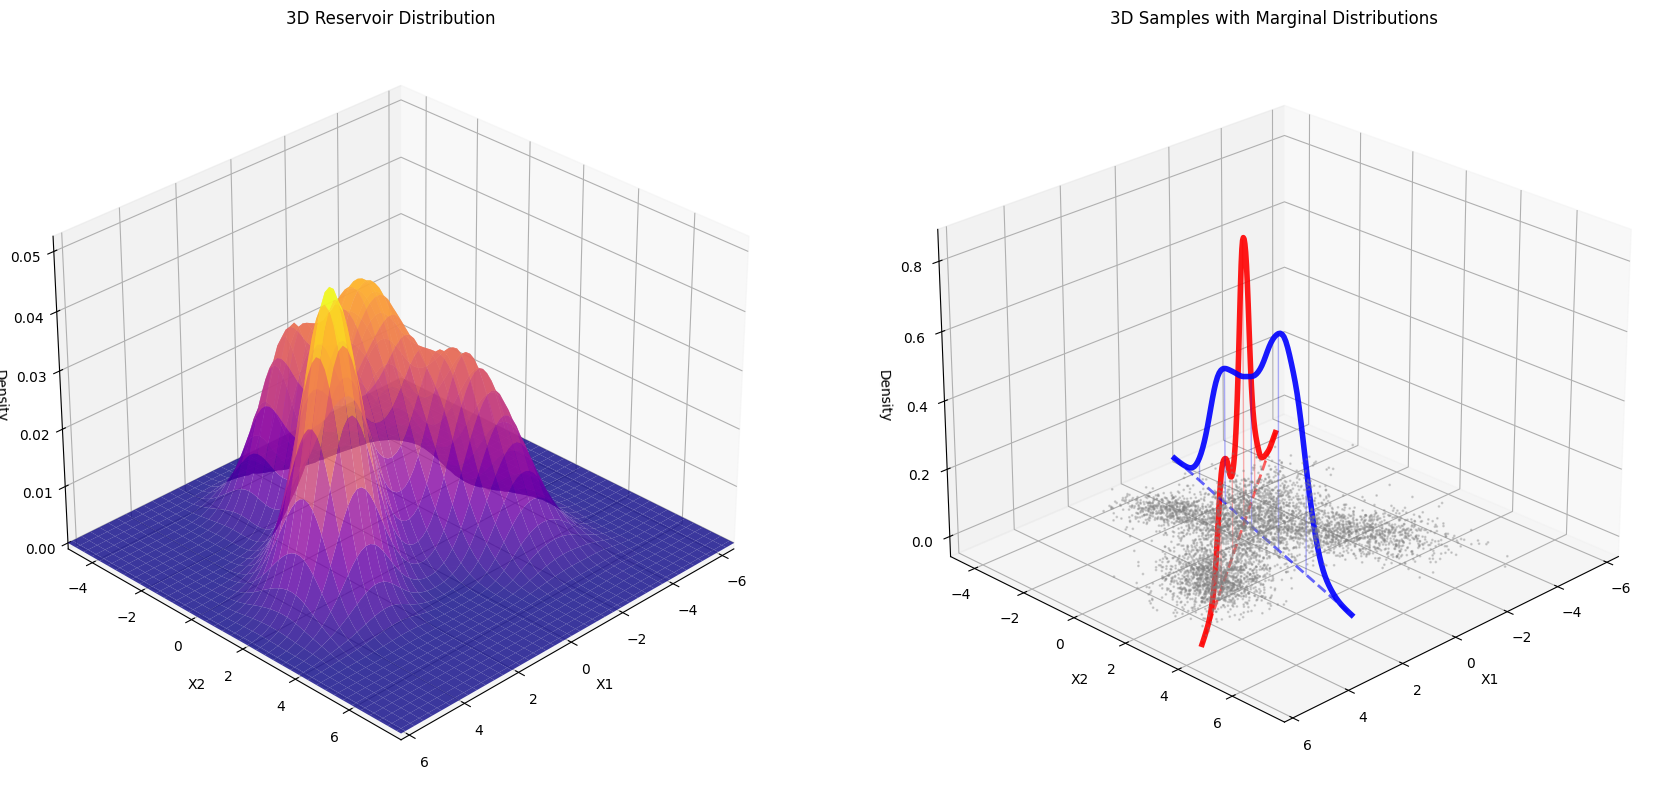


=== MARGINAL STATISTICS ===


ValueError: not enough values to unpack (expected 3, got 2)

In [6]:
# -----------------------------
# 5) Fancy 3D Visualization: Complex Reservoir Distribution with Marginalizations
# -----------------------------

def create_fancy_reservoir(key, n=5000):
    """Create a more complex and visually interesting 2D reservoir distribution"""
    keys = jax.random.split(key, 6)
    
    # Component 1: Elongated Gaussian (main body)
    mean1 = jnp.array([0.0, 0.0])
    # Create elongated covariance matrix
    angle1 = jnp.pi/6  # 30 degrees
    R1 = jnp.array([[jnp.cos(angle1), -jnp.sin(angle1)], 
                    [jnp.sin(angle1), jnp.cos(angle1)]])
    D1 = jnp.array([[2.5, 0], [0, 0.8]])  # Elongated
    cov1 = R1 @ D1 @ R1.T
    
    # Component 2: Circular blob (offset)
    mean2 = jnp.array([3.0, 2.0])
    cov2 = jnp.array([[0.6, 0.1], [0.1, 0.6]])
    
    # Component 3: Another elongated component (different orientation)
    mean3 = jnp.array([-1.5, 2.5])
    angle3 = -jnp.pi/3  # -60 degrees
    R3 = jnp.array([[jnp.cos(angle3), -jnp.sin(angle3)], 
                    [jnp.sin(angle3), jnp.cos(angle3)]])
    D3 = jnp.array([[1.8, 0], [0, 0.5]])
    cov3 = R3 @ D3 @ R3.T
    
    # Component 4: Small tight cluster
    mean4 = jnp.array([1.0, -2.0])
    cov4 = jnp.array([[0.3, -0.1], [-0.1, 0.4]])
    
    # Mixing weights (unequal for more interesting structure)
    weights = [0.4, 0.25, 0.25, 0.1]
    n_components = [int(w * n) for w in weights]
    n_components[-1] = n - sum(n_components[:-1])  # Ensure exact total
    
    # Sample from each component
    samples_list = []
    
    # Component 1
    L1 = jnp.linalg.cholesky(cov1)
    z1 = jax.random.normal(keys[0], (n_components[0], 2)) @ L1.T + mean1
    samples_list.append(z1)
    
    # Component 2
    L2 = jnp.linalg.cholesky(cov2)
    z2 = jax.random.normal(keys[1], (n_components[1], 2)) @ L2.T + mean2
    samples_list.append(z2)
    
    # Component 3
    L3 = jnp.linalg.cholesky(cov3)
    z3 = jax.random.normal(keys[2], (n_components[2], 2)) @ L3.T + mean3
    samples_list.append(z3)
    
    # Component 4
    L4 = jnp.linalg.cholesky(cov4)
    z4 = jax.random.normal(keys[3], (n_components[3], 2)) @ L4.T + mean4
    samples_list.append(z4)
    
    # Combine and shuffle
    all_samples = jnp.vstack(samples_list)
    indices = jax.random.permutation(keys[4], n)
    
    return all_samples[indices]

# Create the fancy reservoir
fancy_key = jax.random.PRNGKey(42)
fancy_reservoir = create_fancy_reservoir(fancy_key, n=5000)

print("Created fancy reservoir with 4 components and complex structure")
print(f"Reservoir shape: {fancy_reservoir.shape}")
print(f"X range: [{jnp.min(fancy_reservoir[:, 0]):.2f}, {jnp.max(fancy_reservoir[:, 0]):.2f}]")
print(f"Y range: [{jnp.min(fancy_reservoir[:, 1]):.2f}, {jnp.max(fancy_reservoir[:, 1]):.2f}]")

# Create 3D visualization using density estimation
from mpl_toolkits.mplot3d import Axes3D

# Create a grid for density estimation
x_range = jnp.linspace(jnp.min(fancy_reservoir[:, 0])-1, jnp.max(fancy_reservoir[:, 0])+1, 50)
y_range = jnp.linspace(jnp.min(fancy_reservoir[:, 1])-1, jnp.max(fancy_reservoir[:, 1])+1, 50)
X, Y = jnp.meshgrid(x_range, y_range)

# Simple 2D density estimation using Gaussian kernels
def gaussian_2d_kde(samples, grid_x, grid_y, bandwidth=0.3):
    """2D Gaussian KDE for density estimation"""
    n_samples = samples.shape[0]
    density = jnp.zeros_like(grid_x)
    
    for i in range(n_samples):
        # Gaussian kernel centered at each sample point
        diff_x = grid_x - samples[i, 0]
        diff_y = grid_y - samples[i, 1]
        kernel = jnp.exp(-(diff_x**2 + diff_y**2) / (2 * bandwidth**2))
        density += kernel
    
    return density / (n_samples * 2 * jnp.pi * bandwidth**2)

# Compute density
print("Computing 2D density...")
Z = gaussian_2d_kde(fancy_reservoir, X, Y, bandwidth=0.4)

# Create 2-subplot visualization: 3D surface + 3D scatter with marginals
fig = plt.figure(figsize=(18, 8))

# Define 2 non-orthogonal marginalization directions for clarity
directions = [
    (jnp.array([0.8, 0.6]), "red"),      # ~37 degrees
    (jnp.array([0.3, 0.954]), "blue")    # ~72 degrees
]

# Left subplot: 3D density surface (improved)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# Use a finer grid for smoother surface
x_fine = jnp.linspace(jnp.min(fancy_reservoir[:, 0])-1, jnp.max(fancy_reservoir[:, 0])+1, 80)
y_fine = jnp.linspace(jnp.min(fancy_reservoir[:, 1])-1, jnp.max(fancy_reservoir[:, 1])+1, 80)
X_fine, Y_fine = jnp.meshgrid(x_fine, y_fine)

# Compute smoother density with better bandwidth
Z_fine = gaussian_2d_kde(fancy_reservoir, X_fine, Y_fine, bandwidth=0.5)

# Plot the main 3D surface with better settings
surf = ax1.plot_surface(np.array(X_fine), np.array(Y_fine), np.array(Z_fine), 
                       cmap='plasma', alpha=0.8, linewidth=0, antialiased=True,
                       rstride=2, cstride=2)  # Reduce stride for smoother appearance

# Add fewer, cleaner contour lines at the base
ax1.contour(np.array(X_fine), np.array(Y_fine), np.array(Z_fine), 
           levels=6, colors='white', alpha=0.3, linewidths=0.8, offset=0)

ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('Density')
ax1.set_title('3D Reservoir Distribution')
ax1.view_init(elev=30, azim=45)

# Right subplot: 3D scatter with marginal distributions along projection lines
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# Plot the sample points in 3D (z=0 plane)
ax2.scatter(np.array(fancy_reservoir[:, 0]), np.array(fancy_reservoir[:, 1]), 
           np.zeros(len(fancy_reservoir)), s=1, alpha=0.3, color='gray')

# For each direction, plot the marginal distribution as a 3D curve
for direction, color in directions:
    # Project samples onto the direction
    projections = fancy_reservoir @ direction
    
    # Create 1D density
    proj_range = jnp.linspace(jnp.min(projections)-0.5, jnp.max(projections)+0.5, 100)
    density_1d = kde_1d(projections, proj_range, bandwidth=0.3)
    
    # Scale density for 3D visualization
    density_scaled = density_1d * 3.0  # Scale factor for visibility
    
    # Create 3D coordinates for the marginal curve
    # The curve will be positioned along the projection direction
    curve_x = []
    curve_y = []
    curve_z = []
    
    for proj_val, dens_val in zip(proj_range, density_scaled):
        # Point on the projection line
        base_point = proj_val * direction
        curve_x.append(base_point[0])
        curve_y.append(base_point[1])
        curve_z.append(dens_val)  # Height represents density
    
    # Plot the marginal distribution as a 3D curve
    ax2.plot(curve_x, curve_y, curve_z, color=color, linewidth=4, alpha=0.9)
    
    # Draw the projection line on the base plane
    proj_line_range = jnp.linspace(jnp.min(proj_range), jnp.max(proj_range), 50)
    line_x = proj_line_range * direction[0]
    line_y = proj_line_range * direction[1]
    line_z = np.zeros(len(proj_line_range))
    ax2.plot(line_x, line_y, line_z, '--', color=color, linewidth=2, alpha=0.6)
    
    # Add vertical lines connecting some points from base to curve
    for i in range(0, len(proj_range), 15):  # Every 15th point
        base_point = proj_range[i] * direction
        ax2.plot([base_point[0], base_point[0]], 
                [base_point[1], base_point[1]], 
                [0, density_scaled[i]], 
                color=color, alpha=0.3, linewidth=1)

ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.set_zlabel('Density')
ax2.set_title('3D Samples with Marginal Distributions')
ax2.view_init(elev=25, azim=45)

# Set same axis limits for both plots for consistency
x_min, x_max = jnp.min(fancy_reservoir[:, 0])-1, jnp.max(fancy_reservoir[:, 0])+1
y_min, y_max = jnp.min(fancy_reservoir[:, 1])-1, jnp.max(fancy_reservoir[:, 1])+1

ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

# Improve the 3D appearance
ax1.zaxis.set_major_locator(plt.MaxNLocator(5))  # Fewer z-axis ticks
ax2.zaxis.set_major_locator(plt.MaxNLocator(5))

plt.tight_layout()
plt.show()

# Print some statistics about the marginals
print("\n=== MARGINAL STATISTICS ===")
for direction, name, color in directions:
    projections = fancy_reservoir @ direction
    mu, var, skew, kurt = central_moments(projections)
    print(f"{name:15s}: μ={mu:6.3f}, σ²={var:6.3f}, skew={skew:6.3f}, kurt={kurt:6.3f}")

print(f"\nThe fancy reservoir shows how different projection directions")
print(f"reveal completely different 1D marginal distributions!")
print(f"This demonstrates the richness of high-dimensional reservoir computing.")



---

### Exporting figures
- Each figure is shown inline; you can also save them (e.g., `plt.savefig("figure.png", dpi=300)`).
- For proposals: consider exporting the 2D scatter and a **3-panel** strip of marginals, plus before/after curves.

### Notes
- You can replace the target mixture with *any* 1D dataset, or change to sliced-cumulant/MMD objectives per your theory doc.
- Swap cubic for a richer readout (e.g., polynomial features or a small MLP) if you want flexibility beyond moments.
